#  Ansambl metode

:::{admonition} Šta ćemo saznati u ovom poglavlju? 
:class: note

- Razumevanje osnovnih principa ansambl metoda.  

- Razumevanje koncepta proste agregacije (engl. bagging).  

- Razumevanje koncepta pojačavanje (engl. boosting).    

- Razumevanje strukture slučajnih šuma.  

- Razumevanje razlike između stabla odlučivanja i slučajnih šuma.  

- Razumevanje načina funkcionisanja slučajnih šuma.  

:::


**Ansambl metode (*engl. ensembles*)** zasnivaju se na ideji da se, umesto jednog modela, koristi više pojedinačnih modela koji su objedinjeni u jedinstven ansambl. Kombinovanjem većeg broja pouzdanih modela smanjuje se uticaj grešaka i postižu se veća tačnost i stabilnost, jer se njihovim zajedničkim delovanjem poništavaju nezavisne ili slabo povezane greške ([1], [2], [3]).


```{admonition} Ideja ansambl učenja zasniva se na jednostavnom, ali snažnom principu 
:class: seealso

Kombinovanjem više nesavršenih procenitelja često se dobija precizniji i robusniji model.

```

S obzirom da jedna hipoteza često nije dovoljna da precizno opiše problem na osnovu raspoloživih podataka, rešenje se nalazi u kombinovanju više različitih modela. Ovakav pristup, koji predstavlja osnovu ansambl učenja, značajno povećava pouzdanost predviđanja.

Dve **ključne strategije** ansambl metoda su:
1. **Prosta agregacija (engl. Bagging)** kombinuje više nezavisno treniranih modela istog tipa na različitim podskupovima podataka, pri čemu se konačni model formira kombinujem (najčešće glasanjem ili prosekom) svih predikcija pojedinačnih modela. Fokus ovog pristupa je da se svaki član ansambla trenira na zasebnom nasumično izvučenom uzorku podataka i da svi modeli unutar ansambla doprinose finalnoj odluci sa identičnim ponderima ( ravnopravno), čime se smanjuje rizik od preprilagođavanja.  Ova metoda smanjuje osetljivost na šum jer kombinuje rezultate više modela obučenih na različitim primerima. Time se neutrališu velika odstupanja, što je veoma važno za modele koji su inače skloni preprilagođavanju podacima. Najpoznatiji primer proste agregacije su slučajne šume (engl. Random Forest) koji nastaje kombinacijom modela stabala odlučivanja.

2. **Pojačavanje (engl. Boosting)** je metoda u kojoj novi modeli uče iz greške prethodnih modela. Pažnja se usmerava na one uzorke koje su prethodni modeli pogrešno klasifikovali, kako bi se ispravili njihovi propusti. Konačna predikcija ansambla se dobija ponderisanim kombinovanjem svih modela, s tim da bolji modeli imaju veći uticaj na konačnu odluku. Primeri pojačavanja uključuju. Proces pojačavanja se odvija kroz niz logičnih koraka koji započinju dodeljivanjem početnih težina svim primerima u skupu podataka. Prvi model se trenira na tako ponderisanim podacima, nakon čega se procenjuje njegova uspešnost. Ključni korak predstavlja ažuriranje težina, pri čemu se primerima koje je model pogrešno klasifikovao dodeljuje veća težina kako bi naredni model mogao da ispravi te greške. Ovi sekvencijalno poređani modeli poznati su kao bazni ili slabi modeli, a njihovim kombinovanjem kreira se snažan ansambl model. Iterativna priroda ovog procesa obezbeđuje sukcesivno korigovanje grešaka, što rezultira robusnim ansamblom koji pokazuje izuzetne performanse u analizi kompleksnih skupova podataka. Primeri metoda pojačavanja uključuju Adaptivno pojačavanje (engl. AdaBoost), Gradientno pojačavanje (engl. Gradient Boosting), Ekstremno gradijentno pojačavanje (engl. XGBoost), LightGBM i CatBoost. 


Ključni izazov nadgledanog učenja ogleda se u uspostavljanju ravnoteže između pristrasnosti i varijanse. Jednostavni modeli često pate od visoke pristrasnosti i nedovoljnog prilagođavanja (*underfitting*), dok kompleksni modeli teže preteranom prilagođavanju šumu u podacima, što dovodi do visoke varijanse i preprilagođavanja (*overfitting*). Ansambl metode rešavaju ovaj problem integracijom više nesavršenih modela, čime se dobija precizniji i stabilniji sistem.  

Tehnike bagginga i boostinga u pravilu dovode do izgradnje robusnijih i tačnijih prediktivnih modela. One efikasno upravljaju kompromisom između pristrasnosti i varijanse, osnovna razlika ogleda se u sledećem:

- **Bagging** smanjuje varijansu tako što trenira modele nezavisno jedne od drugih.  
- **Boosting** smanjuje pristrasnost sekvencijalnim treniranjem modela, pri čemu se svaki naredni model usmerava na greške prethodnih.


**Ključne prekretnice u razvoju Boosting tehnika:**  
Tehniku proste agregacije razvio je Leo Breiman 1994. godine [4], koji je prepoznao potencijal primene bootstrap uzorkovanja ([5]) u mašinskom učenju. Breimanov rad je pokazao da kombinovanjem predikcija više nezavisnih modela može značajno da se smanji nestabilnost pojedinačnih algoritama. Godine 1995, Yoav Freund i Robert Schapire razvili su algoritam AdaBoost [6], prvi praktični algoritam koji je uspešno primenio princip pojačavanja, za šta su nagrađeni prestižnom Gödelovom nagradom zbog značajnog unapređenja preciznosti klasifikacije. Početkom 2000-ih razvijen je algoritam gradijentnog pojačavanja (engl. Gradient Boosting) [7], zasnovan na minimizaciji funkcije gubitka pomoću gradijenta, dok je u periodu između 2014. i 2016. godine predstavljen ekstremni gradijentni boosting (engl. XGBoost) [8], optimizovan za efikasan rad sa velikim skupovima podataka.

Pošto koriste više modela odjednom, ansambl metode troše više procesorskog vremena i memorije nego jedan model. Oni zapravo koriste tu dodatnu snagu računanja kako bi od slabijih algoritama napravili moćniji sistem. Ansambli prevazilaze ograničenja pojedinačnih modela povećanjem broja baznih algoritama, a iako se najčešće koriste sa brzim modelima, kao što su stabla odlučivanja, prednosti ansambla su značajne i kod složenijih i računarski zahtevnijih algoritama.

**Koncept proste agregacije**

Glavna svrha **bagging** metode (*Bootstrap Aggregating*) je redukcija varijanse modela kroz paralelnu obuku više nezavisnih procenitelja na nasumičnim podskupovima podataka. Ovi podskupi se formiraju **bootstrap** metodom, odnosno uzorkovanjem sa ponavljanjem (*sampling with replacement*). 

Rezultati se integrišu putem većinskog glasanja za klasifikacione zadatke ili izračunavanjem proseka za regresione probleme. Zbog svoje prirode, bagging je naročito delotvoran kod nestabilnih algoritama poput stabala odlučivanja.

*Suština metode:*

* **Mehanizam:** Nasumično uzorkovanje sa ponavljanjem (Bootstrap).
* **Proces:** Simultana i nezavisna obuka modela (Paralelizam).
* **Integracija:** Agregacija rezultata putem glasanja ili aritmetičke sredine.
* **Efekat:** Stabilizacija modela i zaštita od preprilagođavanja (*overfitting*).
* **Primena:** * **Finansije:** Procena i predviđanje kreditnog rizika.
    * **Medicina:** Kompleksni sistemi za dijagnostiku.
    * **Industrija:** Optimizacija u operacionim istraživanjima.
    
**Koncept pojačavanja**

**Pojačavanje (engl. *boosting*)** predstavlja naprednu strategiju ansambl učenja koja teži maksimizaciji prediktivne preciznosti kroz sekvencijalnu izgradnju modela. Za razliku od bagging-a, gde modeli rade nezavisno, boosting proces podrazumeva da svaki naredni model direktno uči iz grešaka svojih prethodnika. 

Sistem dinamički prilagođava težine podacima, fokusirajući se na one primere koje je ansambl do tada teško klasifikovao. Kroz ovaj iterativni proces, model progresivno poboljšava performanse na najzahtevnijim delovima skupa podataka, pretvarajući niz slabih procenitelja u jedan visokoprecizan sistem.

*Suština metode:*

* **Mehanizam:** Dinamičko ažuriranje težina (fokus na pogrešno klasifikovane uzorke).
* **Proces:** Sekvencijalna obuka u kojoj svaki novi model koriguju greške prethodnog.
* **Integracija:** Ponderisana agregacija rezultata (modeli sa boljim performansama imaju veći uticaj na finalnu odluku).
* **Efekat:** Primarno smanjenje pristrasnosti (*bias*) i postizanje visoke tačnosti predviđanja.
* **Primena:** * **Finansije:** Napredni sistemi za detekciju prevara (*Fraud Detection*).
    * **Marketing:** Predviđanje odlaska korisnika (*Churn Prediction*).
    * **Tehnologija:** Algoritmi za rangiranje pretraga i preporuke.    

Tabela {numref}`TabelaBaggBoost sumira glavne razlike između Bagging-a i Boosting-a:  

```{table} razlike između Bagging-a i Boosting-a
:label: TabelaBaggBoost
:align: center
:header-rows: 1

| Karakteristika | Bagging | Boosting |
|---|---|---|
| Kako uči | Stvara mnogo nezavisnih modela odjednom | Uči modele jedan za drugim, popravljajući greške prethodnih |
| Šta želi da postigne | Da smanji varijanse i stabilizuje predikcije | Da smanji pristrasnost i poboljša tačnost |
| Kako se nosi sa greškama | Svi uzorci se tretiraju isto | Više pažnje posvećuje pogrešno klasifikovanim uzorcima |
| Prenaučenost | Retko preučen | Može lako da preuči podatke |
| Paralelno treniranje | Može u isto vreme trenirati više modela | Mora sekvencijalno, jedan po jedan |
| Osetljivost na šum | Šum i outlieri ga ne kvare puno | Šum i outlieri mogu da poremete rezultate |


Ansambl metode učenja koriste se i u regresionim i u klasifikacionim problemima.

- U slučaju regresiji, ansambl pristup podrazumeva izgradnju više regresionih modela, poput linearnih, polinomijalnih i sličnih oblika regresije.
- U slučaju klasifikaciji, ansambl pristup obuhvata korišćenje više klasifikacionih modela, kao što su logistička regresija, stabla odlučivanja, KNN i mašine sa potporom vektora algoritmi.



**Ansambl metode i njihove komponente**

Suština ansambl metoda je u kombinovanju više slabih modela (engl. base learners / weak learners) čijom se integracijom formira jedan robustan i jak model (engl. strong learner). Kako bi se postigao ovaj cilj, ansambli se mogu konfigurisati modifikacijom sledećih ključnih komponenti:

- *Različiti algoritmi učenja*   
  Heterogeni ansambli nastaju integracijom suštinski različitih algoritama učenja. Ovim pristupom se iskorišćava činjenica da različiti modeli prave greške na različite načine, čime se njihovom sinergijom postiže veća ukupna preciznost.


- *Varijacije unutar istog algoritma*  
  Homogeni ansambli nastaju integracijom istog tipa modela, ali uz promenu hiperparametara ili treniranjem na različitim podskupovima podataka.
 
 
- *Stohastički pristup obuci*  
   Kombinuju se identični algoritami koji se treniraju na istom skupu podataka, ali sa dodavanjem slučajnosti kroz bootstrap uzorkovanje ili nasumični odabir atributa.
   

- *Uzorci podataka* 
	Strategija proste agregacije kreira nezavisne uzorke sa vraćanjem za svaki model, dok strategija pojačavanje koristi iste podatke, ali sa različitim težinama za uzorke.
    

- *Težine modela*  
  Dok se kod strategije proste agregacije doprinos svakog modela najčešće vrednuje podjednako, strategija pojačavanje dodeljuje veće težine onim modelima koji uspešnije koriguju greške svojih prethodnika.
   

- *Kombinovanje predikcija*  
  Kod podataka klasifikacije, konačan rezultat se najčešće dobija putem prostog ili ponderisanog glasanja, dok se kod problema regresije primenjuje izračunavanje aritmetičke sredine ili ponderisanog proseka dobijenih rezultata.
   

- *Funkcija greške*  
  Glavna razlika je u tome što strategija pojačavanja iterativno minimizuje funkciju greške, dok strategija proste agregacije smanjuje varijansu spajajući više modela odjednom, bez direktnog korišćenja funkcije greške.


**Osnovne koristi primene ansambl metoda**

Ansambl učenje predstavlja fleksibilan pristup koji unapređuje performanse modela mašinskog učenja kroz više važnih dimenzija:

- **Veća tačnost predviđanja:** Kombinovanjem više modela postiže se značajno viši nivo preciznosti u odnosu na pojedinačne modele.  

- **Poboljšana generalizacija:** Ansambli se uspešnije prilagođavaju novim podacima jer istovremeno smanjuju varijansu i pristrasnost.  

- **Ravnoteža između pristrasnosti i varijanse:** Različite ansambl tehnike omogućavaju optimalan kompromis: bagging uglavnom smanjuje varijansu, a boosting pristrasnost.  

- **Manje preprilagođavanje (overfitting):** Kombinovanje više modela smanjuje verovatnoću da model zapamti šum iz trening podataka.  

- **Otpornost na šum i ekstremne vrednosti:** Uticaj netačnih podataka i ekstremnih vrednosti se smanjuje jer se u obir uzima vise rezultata.

- **Metodološka fleksibilnost:** Ansambl pristup se može primeniti na širok spektar algoritama.


*Izazovi i ograničenja ansambl metoda*

Uprkos visokoj efikasnosti ovih metoda, neophodno je uzeti u obzir i određena ograničenja koja prate njihovu praktičnu implementaciju:

* **Računarska zahtevnost:** Treniranje ansambala traje duže i zahteva jači računar jer obrađuje mnogo podataka kroz više različitih modela.  
* **Mana proste agregacije:** Ova metoda nema značajno unapređenje na jednostavne modele koji su već stabilni sami po sebi.
* **Mane pojačavanja:**
    * **Preprilagođavanje:** Model može postati previše složen tako što „nauči napamet” primere iz baze za treniranje, umesto da uči opšta pravila.
    * **Osetljivost na loše podatke:** Veoma je osetljiv na šum i ekstremne vrednosti, jer uporno pokušava da ispravi greške čak i tamo gde su podaci jednostavno netačni.

## Slučajne šume

**Slučajne šume (engl. Random Forest)** je algoritam koji kombinuje mnoštvo stabala odlučivanja kako bi dobio precizniji i stabilniji rezultat. Slučajne šume (Random Forest) funkcionišu na principu integracije mnoštva stabala odlučivanja u jedinstven ansambl sistem. Osnovna ideja je korišćenje kolektivne inteligencije velikog broja stabala kako bi se neutralisale greške pojedinačnih modela i dobio znatno stabilniji i pouzdaniji rezultat predviđanja. Glavna prednost ove metode je uspešno rešavanje problema preprilagođavanja. Finalni rezultat se dobija agregacijom:
 
 - Klasifikacija: U klasifikacionim zadacima, konačna odluka se donosi metodom **većinskog glasanja**. Svako pojedinačno stablo u ansamblu daje svoju predikciju za određenu klasu, a klasa koja prikupi najviše glasova postaje konačno predviđanje. 
 
 - Regresija: U regresionim zadacima, konačna predikcija se dobija izračunavanjem **aritmetičke sredine** svih pojedinačnih predikcija stabala u ansamblu. Svako stablo daje svoje predviđanje za posmatranu opservaciju, a konačna vrednost predstavlja prosečnu vrednost svih predviđanja. 
 
Ovakav pristup omogućava smanjenje grešaka pojedinačnih stabala i daje pouzdanije rezultate u poređenju sa predviđanjem samo jednog stabla.  

Algoritam slučajne šuma utemeljio je Tin Kam Ho (IBM) 1995. godine [9] uvođenjem metode slučajnih podprostora (engl. Random Subspace Method), kojom se stabla odlučivanja obučavaju na nasumično odabranim podskupovima atributa. Ovu ideju je 2001. godine formalizovao i proširio Leo Breiman [10], integrišući bagging sa nasumičnim odabirom atributa pri svakom grananju čvora. 

Već smo diskutovali o tome kako se grade stabla odlučivanja. Bilo bi korisno da se prisetite tih koncepata pre nego što pređemo na sledeći deo.


**Konstrukcija modela slučajnih šuma**

Proces izgradnje zasnovan je na sledećim principima:

1. **Nezavisnost stabala:** Svako stablo u ansamblu gradi se potpuno nezavisno. Algoritam uvodi elemente slučajnosti za svako stablo kako bi se osiguralo da modeli budu međusobno različiti (**dekolerisani**).
2. **Bootstrap uzorkovanje:** Izgradnja pojedinačnog stabla započinje kreiranjem *bootstrap* uzorka. Iz originalnog skupa od $n$ instanci (`n_samples`), nasumično se bira $n$ uzoraka sa ponavljanjem. 
    * **Mehanizam:** Pošto se uzorkovanje vrši sa ponavljanjem, ista instanca može biti odabrana više puta.
    * **Sastav uzorka:** Ovakav skup podataka biće iste veličine kao i originalni, ali će mu nedostajati približno jedna trećina originalnih podataka (tzv. *out-of-bag* podaci), dok će se druge instance ponavljati. 
    
**Primer bootstrap uzorkovanja:**
Pretpostavimo da imamo početnu listu elemenata `['a', 'b', 'c', 'd']`. Mogući *bootstrap* uzorci su:
* `['b', 'd', 'd', 'c']`
* `['d', 'a', 'd', 'a']`


Pri konstruisanju modela slučajnih šuma, osnovni parametar koji je potrebno odrediti jeste broj stabala u ansamblu (parametar `n_estimators` u klasama `RandomForestRegressor` ili `RandomForestClassifier`). 

---

**Modifikacija procesa izgradnje stabla**

Nakon generisanja *bootstrap* uzorka, pristupa se izgradnji stabla odlučivanja uz specifičnu modifikaciju standardnog algoritma. Umesto evaluacije svih dostupnih obeležja pri svakom grananju, uvodi se dodatni nivo randomizacije:

* **Slučajni izbor atributa:** U svakom čvoru, algoritam nasumično bira podskup atributa i traži optimalno razdvajanje isključivo unutar tog podskupa. 
* **Kontrola parametrom `max_features`:** Ovim parametrom određujemo koliko će se atributa nasumično birati. Pošto se ovaj izbor ponavlja iznova u svakom čvoru, svako stablo (i svaki njegov deo) donose odluke na osnovu različitih skupova informacija.

**Prilagođeni proces izgradnje stabla**

Nakon što se napravi *bootstrap* uzorak, počinje izgradnja stabla. Za razliku od običnih stabala odlučivanja, ovde se uvodi dodatna slučajnost pri svakom deljenju podataka (grananju):

* **Slučajni izbor atributa:** Umesto da pregleda sve moguće atribute, algoritam u svakom čvoru nasumično bira samo nekoliko njih i traži najbolje rešenje isključivo među njima.
* **Parametar `max_features`:** Ovim parametrom određujemo koliko će se atributa nasumično birati. Pošto se ovaj izbor ponavlja iznova u svakom čvoru, svako stablo (i svaki njegov deo) donosi odluke na osnovu različitih informacija.

Ovakav postupak sprečava preveliku sličnost stabala, jer ni dominantni atribut nije prisutan u svim podelama, što omogućava i ostalim atributima da doprinesu većoj preciznosti modela.

Dodatno, sinergija mehanizama nasumičnosti doprinosi većoj raznolikosti unutar ansambla i unapređuje ukupne performanse modela. Bootstrap uzorkovanje omogućava da se svako stablo gradi na blago drugačijem skupu podataka, dok nasumičan izbor atributa obezbeđuje da se grananja zasnivaju na različitim atributima. Zajedno, ovi procesi garantuju da su sva stabla u slučajnoj šumi međusobno **dekorelisana**, što je ključno za visoku preciznost i robusnost finalnog modela.

---

**Uticaj parametra `max_features` na proces grananja**

Kritičan parametar u procesu izgradnje slučajnih šuma je `max_features`, koji kontroliše broj atributa koji se razmatraju pri svakom razdvajanju čvora. Njegova vrednost direktno utiče na nivo nasumičnosti:

 - Maksimalna vrednost (max_features = n_features): Svako grananje uzima u obzir sve dostupne atribute. U ovom slučaju nasumičnost pri odabiru obeležja izostaje, a jedini izvor varijacije ostaje bootstrap uzorkovanje.

 - Minimalna vrednost (max_features = 1): Algoritam određuje optimalni prag koristeći samo jedan nasumično izabrani atribut.

 - Implikacije na model: Visoka vrednost ovog parametra dovodi do toga da stabla teže da budu veoma slična (visoka korelacija) jer se često oslanjaju na iste dominantne atribute. Sa druge strane, niska vrednost čini stabla značajno različitim, što obično zahteva veću dubinu pojedinačnih stabala kako bi se podaci adekvatno modelovali.

---

*Generisanje predviđanja u modelu slučajnih šuma*

Proces predviđanja počinje dobijanjem izlaza od svakog stabla u ansamblu. Konačni rezultat se formira agregacijom pojedinačnih predikcija, u zavisnosti od tipa zadatka:

  - Kod regresije: Konačna predviđena vrednost dobija se računanjem aritmetičke sredine (proseka) rezultata svih pojedinačnih stabala.
  - Kod klasifikacije: Najčešće se koristi strategija "mekog glasanja" (engl. soft voting). Svako stablo generiše verovatnoće za sve moguće klase, koje se potom prosekuju na nivou celog ansambla. Model kao konačnu odluku dodeljuje klasu sa najvećom prosečnom verovatnoćom.

**Algoritam treniranja slučajnih šuma**

Algoritam treniranja **slučajnih šuma** primenjuje opštu tehniku **bagging** na stabla odlučivanja.  
Posmatramo trening skup definisan ulaznim podacima $X = \{x_1, \dots, x_\alpha\}$ sa odgovorima $Y = \{y_1, \dots, y_\alpha\}$. Označavamo sa $h_1(x), h_2(x), \dots, h_B(x)$ pojedinačna stabla odlučivanja, gde je $B$ ukupan broj stabala.

1. **Bootstrap uzorkovanje:** Bagging postupak ponavlja sledeće korake: nasumično bira uzorke sa vraćanjem iz trening skupa i trenira stabla na tim uzorcima.  Za $b = 1, \dots, B$:  
   - Nasumično biramo  $n$ primera iz skupa $(X, Y)$ **sa vraćanjem** i označi ih kao $(X^{*}_b, Y^{*}_b)$.  
   - Ostatak podataka koji nije izabran čini *out-of-bag* skup za procenu tačnosti.   
   
2. -**Treniranje stabla:** Trenira se stablo odlučivanja $h^{*}_b$ na uzorku $(X^{*}_b, Y^{*}_b)$.   
   -**Čuvanje stabla:** Svako novo stablo se uključuje u finalni model šume.  
   -**Agregacija:** Ovaj proces se ponavlja $B$ puta, čime se formira ansambl stabala čija agregacija rezultuje konačnim predviđanjem.
   
3. **Evaluacija rezultata**
    Kada su sva stabla trenirana, predikcija za novi podatak se vrši:  
   -Za klasifikacione probleme, konačna predviđena klasa $\hat{Y}$, dobijena agregacijom rezultata svih stabala, definisana je formulom:  
   $$\hat{Y} = \text{mode}\{h_b(x)\}_{b=1}^{B}.$$  
  - Kod regresionih problema, konačna predikcija $\hat{Y}$ se dobija izračunavanjem **aritmetičke sredine** svih pojedinačnih predviđanja:  
   $$\hat{Y} = \frac{1}{B} \sum_{b=1}^{B} h_b(x).$$   
   
4. **Evaluacija modela**    
  - Out-of-bag: greška prosečna greška predikcije instanci koje nisu korišćene za treniranje određenog stabla.
  - Kros-validacija.


**Od ulaznih podataka do skupa stabala: Koraci učenja**

Za ulazne podatke  $ X = x_1, x_2, …, x_n $ i izlazne podatke  $ Y = y_1, y_2, …, y_n $, metoda **bagging** generiše $ B = b_1, b_2, …, b_n $ nasumičnih poduzoraka, pri čemu svaki poduzorak sadrži $ n $ parova ulaz–izlaz $ (X_b, Y_b) $. Nakon toga, na svakom od tih $ B $ poduzoraka treniraju se stabla odlučivanja, predstavljena funkcijama $ h_b(X_b) $, koje preslikavaju ulazne podatke u odgovarajuće konačne izlazne vrednosti $ Y_b $.


**Uticaj *bootstrap* procedure na performanse modela**

Logika ovog pristupa zasnovana je na sledećim postavkama:

* **Smanjenje osetljivosti na šum:** Pojedinačno stablo je vrlo osetljivo na specifičnosti (šum) u podacima. Međutim, prosek predviđanja velikog broja stabala neutrališe te greške, pod uslovom da stabla nisu međusobno slična (korelisana).
* **Dekorelacija stabala:** Ako bismo sva stabla trenirali na istim podacima, dobili bismo identične ili veoma slične modele.
* **Različiti podskupovi:** Bootstrap uzorkovanje nam omogućava da svakom stablu prikažemo drugačiju verziju skupa za obučavanje, čime osiguravamo da svako stablo "nauči" nešto drugačije.

**Random subspace method**  
Random Forest takođe uključuje još jedan važan oblik bagginga, a to je **bagging atributa (engl. feature bagging)** [11], koji je još poznat pod nazivom metoda slučajnog podprostora (engl. Random subspace method) [9]. Ova tehnnika podrazumeva da se u svakom poduzorku koristi slučajno izabran podskup atributa, zapravo se više modela trenira nad različitim nasumično izabranim podskupovima atributa. Navedeni pristup direktno adresira problem visoke korelacije između stabala odlučivanja u situacijama kada određena nezavisna promenljiva poseduje izrazitu prediktivnu moć u odnosu na ostale atribute. Obično se, ako zadatak sadrži $ n $ promenljivih, u svakom poduzorku koristi približno $ \sqrt{n} $ promenljivih. Primena bagging tehnike olakšava rad sa visokodimenzionim podacima, gde veliki broj atributa može dovesti do prenaučenosti pojedinačnih modela, pri čemu smanjuje varijansu modela i ublažava rizik od prenaučenosti, bez povećanja njegove pristrasnosti.  



***
**Parametrizacija: broj stabala**

Broj stabala u ansamblu, označen kao $B$, predstavlja **slobodan parametar** modela čija vrednost direktno utiče na performanse. U praksi se najčešće koristi od nekoliko stotina do nekoliko hiljada stabala, u zavisnosti od dimenzionalnosti i prirode samog skupa podataka za obuku.

> **Metode za određivanje optimalnog broja stabala ($B$):**
> 
> 1. **Unakrsna validacija (*Cross-validation*):** Standardna procedura testiranja modela na različitim podskupovima podataka radi procene generalizacije.
> 2. **Out-of-Bag (OOB) greška:** Ovaj pristup je karakterističan za ansambl metode i omogućava procenu performansi modela bez odvojenog validacionog skupa. OOB greška predstavlja prosečnu grešku predikcija za svaku instancu, pri čemu se u obzir uzimaju samo stabla koja tu instancu nisu koristila tokom procesa bootstrap uzorkovanja.

***

*Zašto je OOB procena korisna u praksi?*

- **Efikasnost računanja:** Procena se vrši paralelno sa treniranjem, čime se eliminiše potreba za dodatnim višestrukim treniranjem modela.  
- **Optimalno korišćenje podataka:** Svi dostupni podaci koriste se za obuku, što je naročito važno u finansijskim modelima sa ograničenim istorijskim podacima.  
- **Pouzdanost:** Rezultati OOB procene uglavnom se slažu sa rezultatima kros-validacije, pružajući realističan uvid u performanse modela na novim, neviđenim podacima.

***

## Prednosti i mane algoritma slučajnih šuma

Primena Random Forest algoritma u analizi podataka donosi brojne prednosti, ali i određene tehničke i interpretativne izazove koje je potrebno uzeti u obzir tokom modelovanja.

*Prednosti algoritma slučajnih šuma*

- **Smanjenje rizika od preprilagođavanja (overfitting):**  
  Pojedinačna stabla odlučivanja imaju tendenciju da se previše prilagode šumu u trening podacima, dok slučajna šuma ovaj problem ublažava agregacijom većeg broja međusobno slabo korelisanih stabala, čime se smanjuju varijansa i ukupna greška predviđanja.

- **Visoka fleksibilnost i robusnost:**  
  Primena slučajnih šuma na podatke u vektorskom obliku obezbeđuje visoku preciznost predviđanja.  Algoritam uspešno rešava i klasifikacione i regresione zadatke uz visok nivo tačnosti. Zahvaljujući mehanizmu nasumičnog izbora atributa (engl. *feature bagging*), model ostaje stabilan čak i u prisustvu nedostajućih podataka, pa se može koristiti i za procenu nedostajućih vrednosti.

- **Jednostavna procena značaja varijabli (feature importance):**  
  Random Forest omogućava kvantifikaciju doprinosa svake ulazne varijable modelu. Najčešće korišćene mere su:
  - **Gini značaj (smanjenje nečistoće):** procenjuje doprinos varijable kroz poboljšanje čistoće čvorova.  
  - **Permutacioni značaj (Mean Decrease Accuracy):** meri pad tačnosti modela nakon nasumičnog mešanja vrednosti varijable u *out-of-bag* uzorcima.

*Mane algoritma slučajnih šuma*
- **Vremenska zahtevnost:**  
  Iako postižu visoku tačnost na velikim skupovima podataka, slučajne šume mogu zahtevati značajno vreme za obuku i predviđanje zbog potrebe da se obradi veliki broj stabala.

- **Velika potrošnja resursa:**  
  Čuvanje i obrada brojnih stabala, kao i rad sa kompleksnim skupovima podataka, mogu zahtevati znatne memorijske i procesorske kapacitete.

- **Otežana interpretacija modela:**  
  Iako pojedinačna stabla odlučivanja odlikuje visoka interpretabilnost, slučajne šume, sastavljene od velikog broja stabala, su zbog svoje kompleksnostisu teže za direktno tumačenje i često se nazivaju „crna kutija“ (engl. black-box modelima). U situacijama gde je važno detaljno objasniti kriterijume donošenja odluka, ovaj algoritam može biti manje pogodan u poređenju sa jednostavnijim i transparentnijim modelima.


```{admonition} Načini generisanja slučajnosti u slučajnim šumama
:class: important

Uvođenje slučajnosti u okviru slučajne šume sprovodi se na dva načina:
* **Na nivou podataka:** Odabirom specifičnih instanci za izgradnju svakog stabla.
* **Na nivou atributa:** Odabirom podskupa atributa pri svakom grananju unutar stabla.

```


## Konfiguracija i obuka algoritma slučajne šume u scikit-learn okruženju

Za ilustraciju rada **slučajne šume** koristićemo isti skup podataka kao i kod stabla odlučivanja **German Credit Dataset** (detalje o bazi možete pronaći [ovde](https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data))). Ova baza je posebno pogodna jer kombinuje numeričke i kategoričke podatke koji direktno utiču na donošenje odluka.

Podsetimo se ključnih detalja o bazi:
* **Kontekst:** Skup sadrži podatke o 1.000 klijenata banke.
* **Struktura:** Svaki klijent je opisan kroz 20 numeričkih i kategoričkih atributa.
* **Cilj:** Binarna klasifikacija klijenata na grupe niskog ili visokog kreditnog rizika.

Ova baza je idealna za prelazak sa pojedinačnog stabla na slučajnu šumu, jer nam omogućava da direktno uporedimo kako ansambl modela obrađuje iste numeričke i kategoričke podatke radi preciznije procene kreditne sposobnosti.

*Priprema radnog okruženja i uvoz biblioteka*  


Svaka od navedenih biblioteka ima precizno definisanu ulogu u procesu mašinskog učenja, kao i u našem algoritmu za izgradnju **slučajnih šuma**. Iako smo mnoge od njih koristili i za pojedinačno stablo odlučivanja, ovde one omogućavaju rad sa ansamblom modela, što značajno doprinosi stabilnosti i tačnosti predviđanja.


**Manipulacija i vizuelizacija podataka**
* **Pandas (`pd`)**: Primarna biblioteka za rad sa tabelarnim podacima. Koristi se za učitavanje podataka, njihovo čišćenje i efikasnu manipulaciju tabelarnim strukturama. 
* **Matplotlib (`plt`)**: Osnovna biblioteka za kreiranje grafikona i vizuelni prikaz rezultata.
* **Seaborn (`sns`)**: Biblioteka za naprednu vizuelizaciju podataka koja je bazirana na Matplotlib-u.

**Biblioteka Scikit-learn (`sklearn`)** 
Ova biblioteka omogućava jednostavnu implementaciju algoritma, pripremu podataka, obuku modela i evaluaciju performansi. U ovom kodu koristimo:

* **Priprema podataka (Preprocessing)**:
    * `train_test_split`: funkcija za podelu skupa podataka na deo za obučavanje i deo za testiranje modela.
    * `OneHotEncoder`: Pretvara kategoričke podatke u numerički format koji algoritam može da obradi.
    * `ColumnTransformer`: Omogućava primenu različitih metoda obrade na različite kolone istovremeno.
    * `Pipeline`: Povezuje sve korake pripreme i sam model u jedan automatizovan proces.

* **Algoritam**:
    * `RandomForestClassifier`: Implementacija algoritma slučajnih šuma koju koristimo za klasifikaciju.

* **Evaluacija modela**:
    * `Accuracy_score`: Izračunava ukupnu tačnost modela.
    * `Classification_report`: Prikazuje detaljan pregled performansi modela,

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

*Učitavanje skupa podataka*

U ovom koraku definišemo internet adresu (engl. URL) koja vodi do **German Credit** skupa podataka. Ovaj dataset je deo čuvenog **UCI Machine Learning Repository** arhiva.

In [31]:
VebAdresa = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

*Definisanje imena kolona*

Radi bolje čitljivost koda, u ovoj fazi manuelno dodeljujemo deskriptivna imena svakom atributu.

In [32]:
columns = [
    "Status_racuna", "Trajanje_kredita", "Kreditna_istorija", "Svrha",
    "Iznos_kredita", "Stednja", "Radni_staz", "Stopa_rata",
    "Licni_status", "Drugi_duznici", "Vreme_stanovanja",
    "Imovina", "Starost", "Drugi_krediti",
    "Stanovanje", "Broj_kredita",
    "Zaposlenost", "Broj_izdrzavanih", "Telefon", "Strani_radnik",
    "Klasa"
]

Učitavamo skup podataka u Pandas DataFrame, pri čemu koristimo `sep=" "` da označimo da su vrednosti odvojene razmakom. Postavljanjem parametra `header=None`označavamo da dataset ne sadrži red sa imenima kolona, dok postavljanjem parametra `names=columns` dodeljujemo nazive kolona onako kako su u prethodnom redu definisani i smešteni u niz `columns`.

Ako se u zagradama ne navede broj, metoda `baza.head()` podrazumevano prikazuje prvih 5 redova skupa podataka.  
Ukoliko se u zagradama navede broj, prikazuju se prvih onoliko redova koliko je zadato. Analogno tome, metoda `baza.tail()` prikazuje poslednjih 5 redova ako broj nije preciziran, odnosno poslednjih onoliko redova koliko je navedeno u zagradama.


In [33]:
baza = pd.read_csv(VebAdresa, sep=" ", header=None, names=columns)
baza.head()

,Status_racuna,Trajanje_kredita,Kreditna_istorija,Svrha,Iznos_kredita,Stednja,Radni_staz,Stopa_rata,Licni_status,Drugi_duznici,...,Imovina,Starost,Drugi_krediti,Stanovanje,Broj_kredita,Zaposlenost,Broj_izdrzavanih,Telefon,Strani_radnik,Klasa
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


Kada pozovemo `baza.describe()` dobijamo statistički sažetak numeričkih kolona skupa podataka:

- **count**: Broj ne-nedostajućih vrednosti u koloni.  
- **mean**: Srednja vrednost (prosek) kolone.  
- **std**: Standardna devijacija (koliko se vrednosti prosečno udaljavaju od srednje vrednosti).  
- **min**: Najmanja vrednost u koloni.  
- **25%**: Donji kvartil (prva četvrtina podataka).  
- **50%**: Medijana (srednja vrednost).  
- **75%**: Gornji kvartil (treća četvrtina podataka).  
- **max**: Najveća vrednost u koloni.  

> Napomena: Standardna metoda `describe()` analizira isključivo **numeričke kolone**. Kako biste dobili uvid i u **kategoričke podatke**, koristite argument `include='all'`, što dodatno vraća:
> - **unique** – broj jedinstvenih vrednosti u koloni
> - **top** – najčešća vrednost (moda)
> - **freq** – frekfencija ponavljanja najčešće vrednosti 

In [34]:
baza.describe()

,Trajanje_kredita,Iznos_kredita,Stopa_rata,Vreme_stanovanja,Starost,Broj_kredita,Broj_izdrzavanih,Klasa
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


Pozovanje metode`.info()` dobijamo izveštaj o strukturi posmatranog skupa podataka, uključujući tip objekta, opsega indeksa, broj redova, listu kolona, broj popunjenih vrednosti za svaki atribut , tip podataka svake kolone, količinu memorije koju zauzima skup podataka. 

> Metod `.info()` je koristan za brzu proveru nedostajućih vrednosti i tipova podataka u skupu podataka.


In [35]:
baza.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
Status_racuna        1000 non-null object
Trajanje_kredita     1000 non-null int64
Kreditna_istorija    1000 non-null object
Svrha                1000 non-null object
Iznos_kredita        1000 non-null int64
Stednja              1000 non-null object
Radni_staz           1000 non-null object
Stopa_rata           1000 non-null int64
Licni_status         1000 non-null object
Drugi_duznici        1000 non-null object
Vreme_stanovanja     1000 non-null int64
Imovina              1000 non-null object
Starost              1000 non-null int64
Drugi_krediti        1000 non-null object
Stanovanje           1000 non-null object
Broj_kredita         1000 non-null int64
Zaposlenost          1000 non-null object
Broj_izdrzavanih     1000 non-null int64
Telefon              1000 non-null object
Strani_radnik        1000 non-null object
Klasa                1000 non-null int64
dtypes: int64(8), ob

*Binarizacija ciljne klase; Razdvajanje podataka na ulazne atribute i izlazne labele*


1. **Binarizacija ciljne klase**: U posmatranoj bazi ciljna promenljiva uzima vrednosti `1` (dobar kreditni rizik) i `2` (loš kreditni rizik). Koristeci metodu `.map()` izvršićemo prekodiranje ovih vrednosti `1` u `1` (dobar klijent), i `2` u `1` (rizičan klijent) radi usklađivanja sa standardima binarne klasifikacije.

2. **Razdvajanje na ulazne atribute i izlazne labele**:
    * **Matrica atributa (`X`)**: Izdvajanjem kolone "`"Klasa"` iz skupa podataka formiramo matricu atributa (nezavisnih promenljivih). Ovi podaci predstavljaju ulazne parametre ($X$) na osnovu kojih model uči da prepoznaje obrasce i donosi predviđanja. 
    * **Izlazna labela (`y`)**: Kolona `"Klasa"` se izdvaja kao **zavisna promenljiva**, odnosno ciljni vektor ($y$), čija se vrednost predviđa na osnovu ulaznih podataka. U kontekstu mašinskog učenja, ovaj vektor predstavlja "labelu" ili tačan odgovor na osnovu kojeg model uči da prepoznaje obrasce i vrši klasifikaciju novih primera.

In [36]:
# Transformacija izlazne labele u binarni oblik
baza["Klasa"] = baza["Klasa"].map({1: 1, 2: 0})

X = baza.drop("Klasa", axis=1)
y = baza["Klasa"]

In [37]:
# One-Hot Encoding kategorijskih promenljivih
X_encoded = pd.get_dummies(X, drop_first=True)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


Pre obučavanja modela, važno je analizirati distribuciju ciljne promenljive (`Klasa`). Za ovu svrhu koristimo funkciju `countplot()` iz biblioteke Seaborn, koja na vizuelno jasan način prikazuje brojnost svake kategorije.


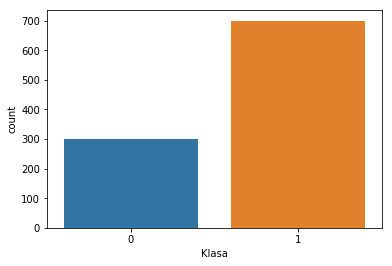

In [39]:
# Draw a Histogram
sns.countplot(data=baza, x="Klasa")

*Analiza uravnoteženosti klasa*

Nakon vizuelnog prikaza, koristimo numeričke funkcije kako bismo precizno izračunali odnos između klasa:

* `np.unique()`: Identifikuje sve jedinstvene oznake koje postoje u koloni `Klasa` (u ovom primeru nule i jedinice).
* `np.bincount()`: Prebrojava koliko se puta svaka od tih oznaka pojavljuje u skupu podataka.
*  Stepen neuravnoteženosti klasa (engl. Imbalance ratio): Odnos dobijenih vrednosti pokazuje kolika je relativna zastupljenost jedne klase u odnosu na drugu

In [40]:
print("Jedinstvene oznake: ", np.unique(baza["Klasa"]))
class_dist = np.bincount(baza["Klasa"])
print("Broj instanci u svakoj klasi:", class_dist)
print("Stepen neuravnoteženosti klasa:", class_dist/np.min(class_dist))

Jedinstvene oznake:  [0 1]
Broj instanci u svakoj klasi: [300 700]
Stepen neuravnoteženosti klasa: [1.         2.33333333]


Skup podataka za predviđanje kreditnog rizika pokazuje određeni stepen neuravnoteženosti. Izračunati odnos zastupljenosti klasa (1 : 2,33) pokazuje da je jedna klasa oko 2,3 puta brojnija od druge.

*Podela na trening i test skup*  

Pomoću funkcije `train_test_split`, ceo skup podataka se deli na test skup i trening skup. 

**Objašnjenje parametara i rezultata:**

* **`train_test_split`** – funkcija koja nasumično deli ulazne podatke na **trening** i **test** podskup, čime omogućava objektivnu procenu performansi modela.  
  - **`X_train, X_test, y_train, y_test`** – funkcija vraća četiri podskupa kako bi se razdvojio proces učenja od procesa evaluacije.
  - **`X_train` i `y_train`** čine trening skup na kojem model „uči“ obrasce iz podataka, gde je *X_train* skup nezavisnih promenljivih, a *y_train* skup zavisnih promenljivih (stvarne ciljne vrednosti ko je kupio proizvod) koji odgovaraju 'X_train' skupu. 
  - **`X_test` i `y_test`** koriste se za proveru koliko je model precizan na podacima koje ranije nije video, gde je *X_test* skup nezavisnih promenljivih na osnovu ovih podataka model vrši predviđanja, a *y_test* skup zavisnih promenljivih (stvarni ishodi za testni skup.).

* **`test_size`** – definiše koliki će procenat ukupnog skupa podataka biti izdvojen za testiranje modela, biramo `test_size = 0.3` kako bi se 30% podataka alociralo za testiranje performansi modela, dok se preostalih 70% koristi za proces treninga.

* **`random_state`** –Koristi se za postizanje reproduktivnosti rezultata. Postavljanje fiksne celobrojne vrednosti omogućava dobijanje identičnih ishoda pri svakom izvršavanju koda, čime se kontroliše slučajnost u procesu izgradnje modela.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = 149)

#prikazujemo veličinu trening i test skupa
print()
print("Trening skup: ", X_train.shape, y_train.shape)
print("Test skup: ", X_test.shape)


Trening skup:  (700, 20) (700,)
Test skup:  (300, 20)


*Normalizacija neprekidnih atributa pomoću MinMaxScaler-a*

Pošto se numeričke promenljive izražavaju u različitim jedinicama i opsezima, potrebno je izvršiti njihovu normalizaciju na interval od 0 do 1.

- **MinMaxScaler**: Metoda koja transformiše vrednosti tako da najmanja vrednost u koloni postaje 0, a najveća 1.  

- **Postupak obrade**:  
  - **fit**: Na osnovu trening skupa određuju se minimalne i maksimalne vrednosti.  
  - **transform**: Naučena transformacija se zatim primenjuje i na trening i na test skup podataka.  

- **Značaj normalizacije**:  
  Ovim postupkom se sprečava da atributi sa velikim numeričkim vrednostima (npr. iznos kredita izražen u hiljadama) imaju veći uticaj od atributa sa manjim vrednostima (npr. trajanje kredita u mesecima) tokom obučavanja modela.

Na kraju, proverom minimalnih i maksimalnih vrednosti potvrđuje se da su svi podaci uspešno preslikani u željeni opseg $[0, 1]$.


In [42]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

kontrolneKolone = ['Trajanje_kredita', 'Iznos_kredita', 'Starost']

scaler.fit(X_train[kontrolneKolone])

X_train[kontrolneKolone] = scaler.transform(X_train[kontrolneKolone])
X_test[kontrolneKolone] = scaler.transform(X_test[kontrolneKolone])

print("Minimum %0.2f i Maximum %0.2f na trening setu" %(np.min(X_train[kontrolneKolone].values), np.max(X_train[kontrolneKolone].values)))

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:334: DataConversionWarning: Data with input dtype int64 were all converted to float64 by MinMaxScaler.
  return self.partial_fit(X, y)
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  if __name__ == '__main__':
C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\indexing.py:543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  self.obj[item] = s


Minimum 0.00 i Maximum 1.00 na trening setu


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  # Remove the CWD from sys.path while we load stuff.
C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\indexing.py:543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  self.obj[item] = s


*Enkodiranje kategoričkih podataka (One-Hot Encoding)*

Naredni blok naredbi služi za pretvaranje **kategorijskih kolona** u numerički oblik pomoću *One-Hot Encoding* metode.

- **OneHotEncoder**: 
Najpre se kreira objekat enkodera:
`encoder = OneHotEncoder(handle_unknown='ignore')`

- `OneHotEncoder()` pretvara svaku kategorijsku vrednost u posebnu binarnu kolonu (0 ili 1).
- `handle_unknown='ignore'` ovaj parametar omogućava stabilan rad modela tako što sprečava grešku u slučaju da se u test skupu pojavi kategorija koja nije bila prisutna u trening skupu, takve vrednosti se jednostavno ignorišu.

Zatim se definiše lista kategorijskih kolona koje treba enkodirati:

`KontrolneKolone = ['Status_racuna', 'Kreditna_istorija', 'Svrha', 'Stednja', 'Licni_status', 'Drugi_duznici', 'Drugi_krediti', 'Stanovanje']`

Ova lista sadrži nazive svih kolona sa tekstualnim (kategorijskim) vrednostima.


- **Proces transformacije**:  
Sledeći korak je učenje enkodera na trening podacima:
- `fit()` identifikuje sve kategorije u svakoj koloni.
- `transform()` pretvara ih u numeričke vektore.
- Važno je da se ovo radi **samo na trening skupu**, kako bi se izbeglo curenje informacija iz test podataka.

- **Rezultat**:  
  Proverom dimenzija pomoću `.shape` može se uočiti povećanje broja kolona, jer svaka pojedinačna kategorija dobija sopstvenu binarnu reprezentaciju.

In [37]:
encoder = OneHotEncoder(handle_unknown = 'ignore')

KontrolneKolone = ['Status_racuna', 'Kreditna_istorija', 'Svrha', 'Stednja', 'Licni_status',
               'Drugi_duznici', 'Drugi_krediti', 'Stanovanje']

encoder.fit(X_train[KontrolneKolone])

X_train_encoded =  encoder.transform(X_train[KontrolneKolone])
X_test_encoded =  encoder.transform(X_test[KontrolneKolone])

X_train_encoded = pd.DataFrame(X_train_encoded.toarray())
X_test_encoded = pd.DataFrame(X_test_encoded.toarray())

X_train = X_train.drop(columns = KontrolneKolone)
X_test = X_test.drop(columns = KontrolneKolone)

X_train = np.concatenate((X_train.values, X_train_encoded.values), axis = 1)
X_test = np.concatenate((X_test.values, X_test_encoded.values), axis = 1)

print("Dimenzije podataka za obučavanje:", X_train.shape)
print("Dimenzije podataka za testiranje:", X_test.shape)

Dimenzije podataka za obučavanje: (700, 49)
Dimenzije podataka za testiranje: (300, 49)


S obzirom na to da su u skupu podataka i dalje prisutne originalne (stare) kolone, ukupan broj kolona je povećan, a kategorijske promenljive još uvek nisu u potpunosti uklonjene. To možemo jasno uočiti pozivanjem funkcije head(), koja prikazuje prvih pet redova tabele i omogućava proveru da li se kategorijske kolone i dalje nalaze u podacima.

In [38]:
pd.DataFrame(X_train).head()

,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
0,0.0357143,0.034561,A73,1,2,A121,0.125,1,A172,2,...,0,0,0,1,0,1,0,0,1,0
1,0.357143,0.167618,A75,3,4,A122,0.607143,1,A173,1,...,0,1,0,0,0,0,1,0,1,0
2,0.107143,0.0632214,A73,2,2,A123,0.321429,1,A173,1,...,0,1,0,0,0,0,1,0,1,0
3,0.464286,0.233887,A73,4,4,A122,0.375,1,A174,1,...,0,1,0,0,0,0,1,0,1,0
4,0.25,0.110232,A74,4,1,A123,0.267857,2,A173,1,...,0,1,0,0,0,1,0,0,1,0


Pozivanjem `pd.DataFrame(X_train).info()` dobijamo da su sve kolone tipa object zato štoX_train više nije **DataFrame**, već je postao **NumPy niz (`ndarray`)**, zato što je za spajanje kolona korišćena funkcija `np.concatenate`. Ova funkcija vraća NumPy niz i time se gubi struktura DataFrame-a, uključujući nazive kolona i indekse.

Da bi se zadržao tabelarni oblik podataka i očuvale informacije o kolonama, umesto `np.concatenate` treba koristiti funkciju `pd.concat`, koja omogućava spajanje podataka uz očuvanje **DataFrame** strukture.


In [59]:
pd.DataFrame(X_train).info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 700 entries, 55 to 961
Data columns (total 49 columns):
Trajanje_kredita    700 non-null float64
Iznos_kredita       700 non-null float64
Radni_staz          700 non-null object
Stopa_rata          700 non-null int64
Vreme_stanovanja    700 non-null int64
Imovina             700 non-null object
Starost             700 non-null float64
Broj_kredita        700 non-null int64
Zaposlenost         700 non-null object
Broj_izdrzavanih    700 non-null int64
Telefon             700 non-null object
Strani_radnik       700 non-null object
0                   700 non-null float64
1                   700 non-null float64
2                   700 non-null float64
3                   700 non-null float64
4                   700 non-null float64
5                   700 non-null float64
6                   700 non-null float64
7                   700 non-null float64
8                   700 non-null float64
9                   700 non-null float64
10   

In [43]:
KontrolneKolone = ['Status_racuna', 'Kreditna_istorija', 'Svrha', 'Stednja', 'Licni_status',
               'Drugi_duznici', 'Drugi_krediti', 'Stanovanje', 'Radni_staz', 'Imovina', 'Zaposlenost','Telefon','Strani_radnik']

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore') 

encoder.fit(X_train[KontrolneKolone])

# Transformacija
X_train_encoded = encoder.transform(X_train[KontrolneKolone])
X_test_encoded = encoder.transform(X_test[KontrolneKolone])

# Pretvaranje u DataFrame
X_train_encoded = pd.DataFrame(
    X_train_encoded.toarray(),
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded.toarray(),
    index=X_test.index
)

# Izbacivanje kategorijskih kolona
X_train = X_train.drop(columns=KontrolneKolone)
X_test = X_test.drop(columns=KontrolneKolone)

# Spajanje pomoću concat (NE numpy!)
X_train = pd.concat([X_train, X_train_encoded], axis=1)
X_test = pd.concat([X_test, X_test_encoded], axis=1)		   

In [47]:
print(type(X_train)) # proveravamo da li je pandas DataFrame   
print(X_train.shape)
print(X_train.dtypes.unique()) 

<class 'pandas.core.frame.DataFrame'>
(700, 61)
[dtype('float64') dtype('int64')]


In [45]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 700 entries, 55 to 961
Data columns (total 61 columns):
Trajanje_kredita    700 non-null float64
Iznos_kredita       700 non-null float64
Stopa_rata          700 non-null int64
Vreme_stanovanja    700 non-null int64
Starost             700 non-null float64
Broj_kredita        700 non-null int64
Broj_izdrzavanih    700 non-null int64
0                   700 non-null float64
1                   700 non-null float64
2                   700 non-null float64
3                   700 non-null float64
4                   700 non-null float64
5                   700 non-null float64
6                   700 non-null float64
7                   700 non-null float64
8                   700 non-null float64
9                   700 non-null float64
10                  700 non-null float64
11                  700 non-null float64
12                  700 non-null float64
13                  700 non-null float64
14                  700 non-null float64


In [48]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators = 100, random_state = 1402)
random_forest.fit(X_train, y_train)

# accuracy: (tp + tn) / (p + n)
print("Training accuracy: ", random_forest.score(X_train, y_train))
print("Test accuracy: ", random_forest.score(X_test, y_test))

Training accuracy:  1.0
Test accuracy:  0.77


Preciznost za klasu klijente visokog rizika (lose klijente): 0.7058823529411765
Preciznost za klasu klijente niskog rizika (dobre klijente): 0.7831325301204819
Odziv za klasu klijente visokog rizika (lose klijente): 0.4
Odziv za klasu klijente niskog rizika (dobre klijente): 0.9285714285714286
F1 score za klasu klijente visokog rizika (lose klijente): 0.5106382978723405
F1 score za klasu klijente niskog rizika (dobre klijente): 0.8496732026143791


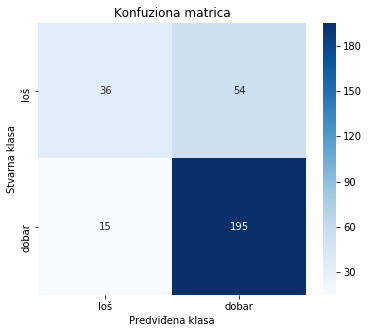

In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predikcija na test skupu
y_pred = random_forest.predict(X_test)

# -----------------------------
# Preciznost (Precision)
# -----------------------------
precision_los = precision_score(y_test, y_pred, pos_label=0)
precision_dobar = precision_score(y_test, y_pred, pos_label=1)
print("Preciznost za klasu klijente visokog rizika (lose klijente):", precision_los)
print("Preciznost za klasu klijente niskog rizika (dobre klijente):", precision_dobar)

# -----------------------------
# Odziv (Recall)
# -----------------------------
recall_los = recall_score(y_test, y_pred, pos_label=0)
recall_dobar = recall_score(y_test, y_pred, pos_label=1)
print("Odziv za klasu klijente visokog rizika (lose klijente):", recall_los)
print("Odziv za klasu klijente niskog rizika (dobre klijente):", recall_dobar)

# -----------------------------
# F1 Score
# -----------------------------
f1_los = f1_score(y_test, y_pred, pos_label=0)
f1_dobar = f1_score(y_test, y_pred, pos_label=1)
print("F1 score za klasu klijente visokog rizika (lose klijente):", f1_los)
print("F1 score za klasu klijente niskog rizika (dobre klijente):", f1_dobar)

# -----------------------------
# Konfuziona matrica
# -----------------------------
conf_mat = confusion_matrix(y_test, y_pred, labels=np.unique(y_train))

plt.figure(figsize=(6,5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['loš', 'dobar'],
            yticklabels=['loš', 'dobar'])
plt.ylabel('Stvarna klasa')
plt.xlabel('Predviđena klasa')
plt.title('Konfuziona matrica')
plt.show()


## Adaptivno pojačavanje

**Adaptivno pojačavanje** (engl. Adaptive Boosting, AdaBoost) predstavlja jedan od prvih i najuticajnijih modela u okviru porodice *boosting* algoritama. Njegova suština leži u iterativnom procesu učenja koji teži kontinuiranoj samokorekciji. Dok na samom početku procesa svi podaci imaju jednak značaj, AdaBoost nakon svakog obučeno stabla vrši automatsku rekalibraciju težina. Ovaj algoritam predstavlja prvi praktično primenljiv boosting pristup koji je uspešno objedinio skup slabih učenika u snažan model [6], za šta su njegovi autori 2003. godine nagrađeni prestižnom Gödelovom nagradom iz oblasti teorijskog računarstva.

> **Mehanizam fokusiranja:** > Algoritam detektuje pogrešno klasifikovane primere i dodeljuje im veću težinu u narednoj iteraciji. Time se sledeći model u nizu „primorava“ da se intenzivnije bavi upravo onim podacima koji su za prethodnike bili problematični. 

Ovaj proces se ciklično ponavlja sve dok se **rezidualna greška** (razlika između stvarnih i predviđenih vrednosti) ne spusti ispod prihvatljivog praga ili dok se ne dostigne maksimalan broj iteracija.

***

**Karakteristike i ograničenja u primeni**

* **Stabilnost:** Može se efikasno koristiti sa velikim brojem prediktora, pri čemu je često manje osetljiv na hiperparametre u poređenju sa nekim savremenijim metodama.
* **Primarna namena:** Smatra se izuzetno pogodnim rešenjem za probleme **klasifikacije**.
* **Ograničenja:** Model pokazuje slabije performanse u uslovima visoke korelacije između karakteristika (*features*) ili kod ekstremno visoke dimenzionalnosti podataka. Takođe, zbog fokusa na greške, može biti osetljiv na šum i ekstremne vrednosti (*outliers*).


**Rangiranje značaja atributa**

Rangiranje značaja atributa u algoritmu slučajnih šuma može se sprovesti prema pristupu Breimana [1], a sama metodologija je i integrisana u standardnoj `scikit-learn` biblioteci. 
Procedura evaluacije značaja atributa u skupu podataka $D_n = \{(X_i, Y_i)\}_{i=1}^n$ sprovodi se kroz sledeće faze:

1. **Obučavanje modela:** Inicijalni korak podrazumeva fitovanje modela slučajnih šuma.
2. **Evidencija greške:** Za svaku instancu registruje se **out-of-bag (OOB)** greška.
3. **Agregacija rezultata:** Izračuna se prosečna vrednost dobijenih grešaka u okviru ansambla. 


**Merenje značaja** $j$-tog obeležja (atributa) procenjuje se kroz sledeći postupak:

1. **Permutacija vrednosti:** Vrednosti posmatranog $j$-tog obeležja se nasumično permutuju unutar skupa podataka za obučavanje, čime se narušava njegova stvarna veza sa ciljnom promenljivom.
2. **Rekalkulacija greške:** Na ovako izmenjenom (perturbovanom) skupu podataka ponovo se izračunava **out-of-bag (OOB)** greška.
3. **Izračunavanje vrednosti značaja (engl. Importance Score):** Mera značaja $j$-tog obeležja dobija se kao prosečna vrednost ovih razlika u OOB greškama pre i nakon permutacije, na nivou svih stabala u ansamblu.
4. **Normalizacija:** Radi obezbeđivanja uporedivosti, ovaj rezultat se normalizuje standardnom devijacijom uočenih razlika.

> **Suština:** Što je veći porast greške nakon permutacije obeležja, to je taj atribut značajniji za prediktivnu moć modela.

### Literatura
[1] Opitz, D.; Maclin, R. (1999). “Popular ensemble methods: An empirical study”. Journal of Artificial Intelligence
Research 11: 169–198. doi:10.1613/jair.614.
[2] Polikar, R. (2006). “Ensemble based systems in decision
making”. IEEE Circuits and Systems Magazine 6 (3): 21–45. doi:10.1109/MCAS.2006.1688199.
[3] Rokach, L. (2010). “Ensemble-based classifiers”.
Artificial Intelligence Review 33 (1-2): 1–39.
doi:10.1007/s10462-009-9124-7.  
[4] Breiman, L. (1996). Bagging predictors. Machine learning, 24(2), 123-140.  
[5] Efron, B. (1979). Bootstrap methods: another look at the jackknife Ann. Stat., Beachood, 7.  
[6] Freund, Y., & Schapire, R. E. (1995, March). A desicion-theoretic generalization of on-line learning and an application to boosting. In European conference on computational learning theory (pp. 23-37). Berlin, Heidelberg: Springer Berlin Heidelberg.  
[7] Friedman, J. H. (2002). Stochastic gradient boosting. Computational statistics & data analysis, 38(4), 367-378.   
[8] Chen, T., & Guestrin, C. (2016, August). Xgboost: A scalable tree boosting system. In Proceedings of the 22nd acm sigkdd international conference on knowledge discovery and data mining (pp. 785-794).  
[9] Ho, T. K. (1995). Random decision forests. Proceedings of 3rd International Conference on Document Analysis
and Recognition, 1, 278-282.  
[10] Breiman, L. (2001). Random forests. Machine Learning, 45(1), 5-32.  
[11] Bryll, R., Gutierrez-Osuna, R., & Quek, F. (2003). Attribute bagging: improving accuracy of classifier ensembles by using random feature subsets. Pattern recognition, 36(6), 1291-1302.
